# Papcorns Data Scientist Technical Assessment

**Candidate:** Sena Kılınç  
**Role:** Jr. Data Scientist  
**Date:** 24 May 2026

## 0. Setup

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

conn = sqlite3.connect("papcorns.sqlite")

def q(sql: str) -> pd.DataFrame:
    """Run a SQL query and return a DataFrame."""
    return pd.read_sql_query(sql, conn)

print("Connected. Tables:", q("SELECT name FROM sqlite_master WHERE type='table'")["name"].tolist())

Connected. Tables: ['users', 'user_events']


### Quick data exploration

In [2]:
print("=== users (first 5) ===")
display(q("SELECT * FROM users LIMIT 5"))

print("\n=== user_events (first 10) ===")
display(q("SELECT * FROM user_events LIMIT 10"))

print("\n=== Row counts ===")
display(q("""
    SELECT 'users' AS tbl, COUNT(*) AS rows FROM users
    UNION ALL
    SELECT 'user_events' AS tbl, COUNT(*) AS rows FROM user_events
"""))

print("\n=== Event types ===")
display(q("SELECT event_name, COUNT(*) AS cnt FROM user_events GROUP BY event_name ORDER BY cnt DESC"))

=== users (first 5) ===


,id,created_at,attribution_source,country,name
0,1,2024-05-07T00:00:00,instagram,US,Eve Brown
1,2,2024-10-12T00:00:00,instagram,NL,Frank Moore
2,3,2024-10-15T00:00:00,tiktok,TR,Ivy Anderson
3,4,2024-08-28T00:00:00,tiktok,TR,Alice Brown
4,5,2024-04-03T00:00:00,organic,NL,Bob Moore



=== user_events (first 10) ===


,id,created_at,user_id,event_name,amount_usd
0,1,2024-05-07T00:00:00,1,app_install,NaN
1,2,2024-05-12T00:00:00,1,trial_started,NaN
2,3,2024-05-24T00:00:00,1,trial_cancelled,NaN
3,4,2024-10-12T00:00:00,2,app_install,NaN
4,5,2024-10-13T00:00:00,2,trial_started,NaN
5,6,2024-10-20T00:00:00,2,subscription_started,8.99
6,7,2024-11-19T00:00:00,2,subscription_renewed,8.99
7,8,2024-12-19T00:00:00,2,subscription_renewed,8.99
8,9,2025-01-18T00:00:00,2,subscription_renewed,8.99
9,10,2025-02-12T00:00:00,2,subscription_cancelled,NaN



=== Row counts ===


,tbl,rows
0,users,1002
1,user_events,3486



=== Event types ===


,event_name,cnt
0,app_install,1002
1,subscription_renewed,750
2,trial_started,682
3,subscription_started,481
4,subscription_cancelled,370
5,trial_cancelled,201


## Task 1. Total Subscription Revenue by Country

### **Definition:** Revenue = `subscription_started` + `subscription_renewed` events (the only rows that carry an `amount_usd`).

,country,total_revenue_usd,paying_users,total_transactions
0,US,4035.96,161,404
1,NL,3335.29,149,371
2,TR,2275.44,171,456


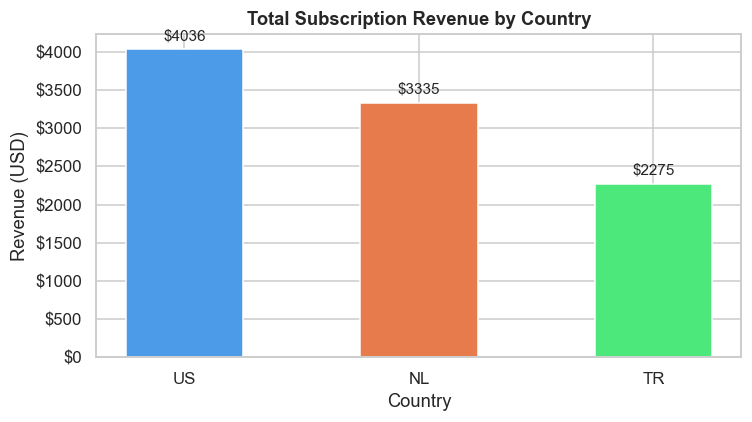

Insight: US leads with $4,035.96 in revenue (41.8% of total $9,646.69) across 161 paying users. TR has the most paying users (171) yet the lowest revenue, indicating a lower price point.


In [3]:
sql_t1 = """
SELECT
    u.country,
    ROUND(SUM(e.amount_usd), 2)      AS total_revenue_usd,
    COUNT(DISTINCT e.user_id)        AS paying_users,
    COUNT(*)                         AS total_transactions
FROM user_events e
JOIN users u ON u.id = e.user_id
WHERE e.event_name IN ('subscription_started', 'subscription_renewed')
GROUP BY u.country
ORDER BY total_revenue_usd DESC
"""

df1 = q(sql_t1)
display(df1)

# Country-to-color map so colors stay consistent across tasks
COUNTRY_COLORS = {"US": "#4C9BE8", "NL": "#E87B4C", "TR": "#4CE87B"}
colors_t1 = [COUNTRY_COLORS[c] for c in df1["country"]]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(df1["country"], df1["total_revenue_usd"], color=colors_t1, width=0.5)
ax.bar_label(bars, fmt="$%.0f", padding=4, fontsize=10)
ax.set_title("Total Subscription Revenue by Country", fontweight="bold")
ax.set_ylabel("Revenue (USD)")
ax.set_xlabel("Country")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("$%.0f"))
plt.tight_layout()
plt.show()

top   = df1.iloc[0]
total = df1["total_revenue_usd"].sum()
print(
    f"Insight: {top['country']} leads with ${top['total_revenue_usd']:,.2f} in revenue "
    f"({top['total_revenue_usd']/total*100:.1f}% of total ${total:,.2f}) "
    f"across {top['paying_users']} paying users. "
    f"TR has the most paying users ({df1[df1['country']=='TR']['paying_users'].values[0]}) "
    f"yet the lowest revenue, indicating a lower price point."
)

## Task 2. Total Trials from Instagram Users

### **Definition:** Count `trial_started` events for users whose `attribution_source = 'instagram'`.

In [4]:
sql_t2 = """
SELECT
    COUNT(*) AS total_trials_instagram,
    COUNT(DISTINCT e.user_id) AS unique_users_trialed
FROM user_events e
JOIN users u ON u.id = e.user_id
WHERE u.attribution_source = 'instagram' AND e.event_name = 'trial_started'
"""

df2 = q(sql_t2)
display(df2)

trials = int(df2.iloc[0]["total_trials_instagram"])
users  = int(df2.iloc[0]["unique_users_trialed"])
print(
    f"Insight: Instagram drove {trials} trials from {users} unique users. "
    f"The 1:1 ratio (trials == unique users) confirms each Instagram user "
    f"started at most one trial , no duplicate trial events for this channel."
)

,total_trials_instagram,unique_users_trialed
0,210,210


Insight: Instagram drove 210 trials from 210 unique users. The 1:1 ratio (trials == unique users) confirms each Instagram user started at most one trial , no duplicate trial events for this channel.


## Task 3. Acquisition Channel Categorisation

### **Logic:** `instagram` and `tiktok` -> **Paid**; `organic` -> **Organic**.

Sample (first 10 rows):


,id,name,country,attribution_source,acquisition_channel
0,1,Eve Brown,US,instagram,Paid
1,2,Frank Moore,NL,instagram,Paid
2,3,Ivy Anderson,TR,tiktok,Paid
3,4,Alice Brown,TR,tiktok,Paid
4,5,Bob Moore,NL,organic,Organic
5,6,Frank Miller,TR,tiktok,Paid
6,7,Henry Moore,US,instagram,Paid
7,8,Alice Moore,TR,tiktok,Paid
8,9,Frank Anderson,US,organic,Organic
9,10,David Anderson,US,organic,Organic



Distribution by acquisition_channel:


,channel,user_count
0,Paid,658
1,Organic,344


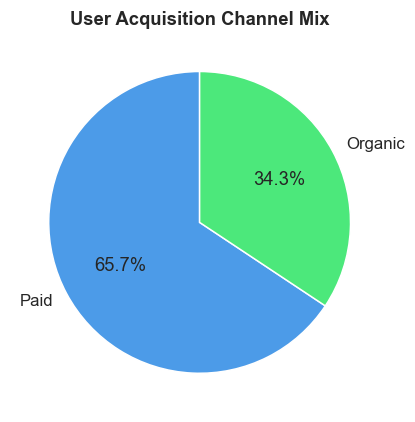

Insight: 658 users (65.7%) were acquired via Paid channels (Instagram + TikTok), while 344 (34.3%) came organically. Paid dominates acquisition, understanding CAC vs LTV for each channel is key.


In [5]:
sql_t3 = """
SELECT
    id,
    name,
    country,
    attribution_source,
    CASE
        WHEN attribution_source IN ('instagram', 'tiktok') THEN 'Paid'
        ELSE 'Organic'
    END AS acquisition_channel
FROM users
ORDER BY id
"""

df3 = q(sql_t3)

print("Sample (first 10 rows):")
display(df3.head(10))

print("\nDistribution by acquisition_channel:")
dist = (
    df3["acquisition_channel"]
    .value_counts()
    .rename_axis("channel")
    .reset_index(name="user_count")  
)
display(dist)

# Pie chart with deterministic color assignment
CHANNEL_COLORS = {"Paid": "#4C9BE8", "Organic": "#4CE87B"}
pie_colors = [CHANNEL_COLORS[c] for c in dist["channel"]]

fig, ax = plt.subplots(figsize=(5, 4))
ax.pie(
    dist["user_count"],
    labels=dist["channel"],
    autopct="%1.1f%%",
    colors=pie_colors,
    startangle=90,
    wedgeprops=dict(edgecolor="white"),
)
ax.set_title("User Acquisition Channel Mix", fontweight="bold")
plt.tight_layout()
plt.show()

paid_n    = int(dist.loc[dist["channel"] == "Paid",    "user_count"].values[0])
organic_n = int(dist.loc[dist["channel"] == "Organic", "user_count"].values[0])
total_n   = paid_n + organic_n
print(
    f"Insight: {paid_n} users ({paid_n/total_n*100:.1f}%) were acquired via Paid channels "
    f"(Instagram + TikTok), while {organic_n} ({organic_n/total_n*100:.1f}%) came organically. "
    f"Paid dominates acquisition, understanding CAC vs LTV for each channel is key."
)

## Task 4. Trial-to-Subscription Conversion Rate

### **Definition:** A user *converts* if they have both a `trial_started` and a `subscription_started` event.  
### Conversion rate = converting users / users who started a trial.

In [6]:
# Data Quality Check
temporal_check = q("""
SELECT COUNT(*) AS violation_count
FROM
    (SELECT user_id, MIN(created_at) AS trial_date
     FROM user_events
     WHERE event_name = 'trial_started'
     GROUP BY user_id) t
JOIN
    (SELECT user_id, MIN(created_at) AS sub_date
     FROM user_events
     WHERE event_name = 'subscription_started'
     GROUP BY user_id) s
ON t.user_id = s.user_id
WHERE s.sub_date < t.trial_date
""")

violations = int(temporal_check.iloc[0, 0])

if violations == 0:
    print("+ Temporal ordering valid. Proceeding with conversion rate analysis.")
else:
    print(f"! WARNING: {violations} users have subscription before trial.")
    print("Conversion rate may be overstated. Investigate before proceeding.")

+ Temporal ordering valid. Proceeding with conversion rate analysis.


In [7]:
# 4a: Overall conversion rate
sql_t4_overall = """
SELECT
    COUNT(DISTINCT t.user_id)  AS trialed_users,
    COUNT(DISTINCT s.user_id)  AS converted_users,
    ROUND(100.0 * COUNT(DISTINCT s.user_id) / COUNT(DISTINCT t.user_id), 2) AS conversion_rate_pct
FROM
    (SELECT DISTINCT user_id FROM user_events WHERE event_name = 'trial_started') t
LEFT JOIN
    (SELECT DISTINCT user_id FROM user_events WHERE event_name = 'subscription_started') s
    ON s.user_id = t.user_id
"""

df4_overall = q(sql_t4_overall)
print("Overall conversion rate:")
display(df4_overall)

Overall conversion rate:


,trialed_users,converted_users,conversion_rate_pct
0,682,481,70.53


In [8]:
# 4b: Conversion rate by attribution_source
sql_t4_by_source = """
SELECT
    u.attribution_source,
    COUNT(DISTINCT t.user_id)  AS trialed_users,
    COUNT(DISTINCT s.user_id)  AS converted_users,
    ROUND(100.0 * COUNT(DISTINCT s.user_id) / COUNT(DISTINCT t.user_id), 2) AS conversion_rate_pct
FROM users u
JOIN
    (SELECT DISTINCT user_id FROM user_events WHERE event_name = 'trial_started') t ON t.user_id = u.id
LEFT JOIN
    (SELECT DISTINCT user_id FROM user_events WHERE event_name = 'subscription_started') s ON s.user_id = u.id
GROUP BY u.attribution_source
ORDER BY conversion_rate_pct DESC
"""

df4_source = q(sql_t4_by_source)
print("\nConversion rate by attribution_source:")
display(df4_source)


Conversion rate by attribution_source:


,attribution_source,trialed_users,converted_users,conversion_rate_pct
0,organic,236,169,71.61
1,instagram,210,149,70.95
2,tiktok,236,163,69.07


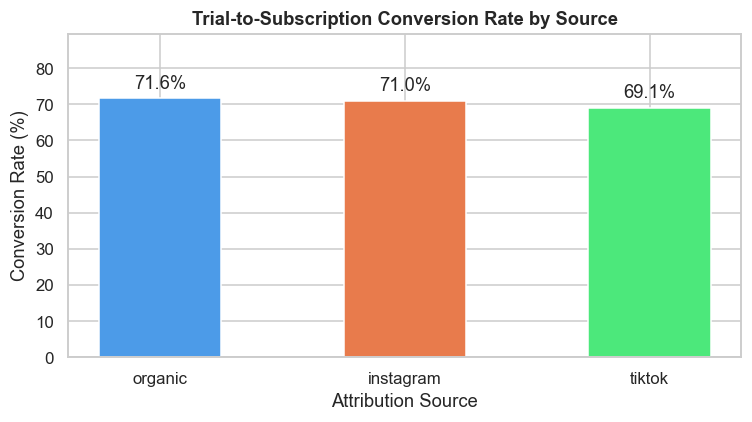

Chi-square test: χ²=0.393, p=0.822, df=2
--> No statistically significant difference across channels (p=0.822 ≥ 0.05)


In [9]:
from scipy.stats import chi2_contingency

# Chart
SOURCE_COLORS = {"organic": "#4C9BE8", "instagram": "#E87B4C", "tiktok": "#4CE87B"}
colors_t4 = [SOURCE_COLORS[s] for s in df4_source["attribution_source"]]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    df4_source["attribution_source"],
    df4_source["conversion_rate_pct"],
    color=colors_t4, width=0.5
)
ax.bar_label(bars, fmt="%.1f%%", padding=4)
ax.set_title("Trial-to-Subscription Conversion Rate by Source", fontweight="bold")
ax.set_ylabel("Conversion Rate (%)")
ax.set_xlabel("Attribution Source")
ax.set_ylim(0, df4_source["conversion_rate_pct"].max() * 1.25)
plt.tight_layout()
plt.show()

best  = df4_source.iloc[0]
worst = df4_source.iloc[-1]
overall_rate = float(df4_overall.iloc[0]["conversion_rate_pct"])


# Chi-Square Test
contingency = pd.DataFrame({
    'converted':     df4_source['converted_users'].values,
    'not_converted': (df4_source['trialed_users'] - df4_source['converted_users']).values
}, index=df4_source['attribution_source'].values)

chi2, p_value, dof, _ = chi2_contingency(contingency)

print(f"Chi-square test: χ²={chi2:.3f}, p={p_value:.3f}, df={dof}")
if p_value < 0.05:
    print("--> Conversion rates differ significantly across channels (p < 0.05)")
else:
    print(f"--> No statistically significant difference across channels (p={p_value:.3f} ≥ 0.05)")


In [10]:
print(
    f"Insight: Overall trial-to-subscription conversion is {overall_rate:.1f}% "
    f"a strong signal that users who start a trial are highly engaged. "
    f"'organic' converts best at {best['conversion_rate_pct']:.2f}% "
    f"({int(best['converted_users'])}/{int(best['trialed_users'])} users), while "
    f"'tiktok' is lowest at {worst['conversion_rate_pct']:.2f}%. "
    f"The spread across channels is narrow (~2.5 pp). "
    f"A chi-square test confirms this difference is not statistically significant "
    f"(χ²=0.393, p=0.822), suggesting conversion is driven more by product experience "
    f"than acquisition source."
)

Insight: Overall trial-to-subscription conversion is 70.5% a strong signal that users who start a trial are highly engaged. 'organic' converts best at 71.61% (169/236 users), while 'tiktok' is lowest at 69.07%. The spread across channels is narrow (~2.5 pp). A chi-square test confirms this difference is not statistically significant (χ²=0.393, p=0.822), suggesting conversion is driven more by product experience than acquisition source.


## Task 5. Median Subscription Duration (Months) by Country

### **Assumptions:**
### - Duration = days between `subscription_started` and `subscription_cancelled`.
### - **Active subscribers** (no cancellation event yet) are treated as still active: their duration is measured from subscription start to the analysis date (`2025-07-12` latest event date in DB, determined dynamically), giving a **conservative lower bound** for the active cohort.
### - 1 month ≈ 30.44 days (average calendar month).
### - Per-user aggregation is done in SQL; Python computes the final median (SQLite has no built-in `MEDIAN`).

Analysis date (max event date in DB): 2025-07-12


,country,median_duration_months
1,TR,3.06
0,NL,2.73
2,US,2.56


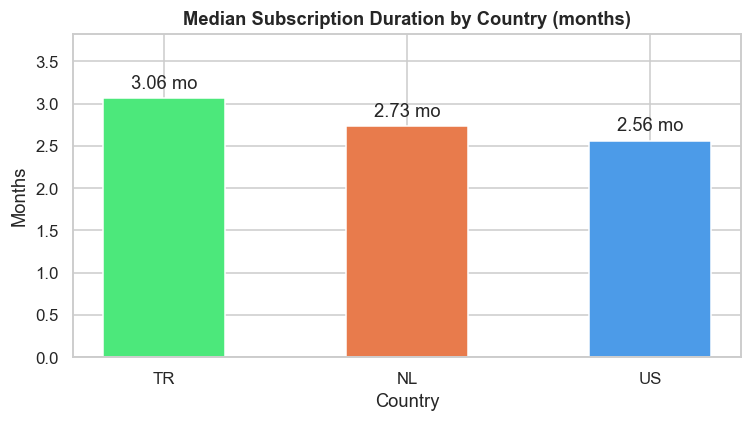

Note: Active subscribers contribute a censored (lower-bound) duration up to 2025-07-12. Insight: TR has the longest median subscription duration (3.06 months), despite having the lowest price point. This may reflect genuine higher retention, a younger cohort with fewer accumulated cancellations, or censoring bias. TR's active subscribers inflate the median since their true end date is unknown. US has the shortest median (2.56 months), consistent with an older cohort that has had more time to churn.


In [11]:
ANALYSIS_DATE = q("SELECT MAX(created_at) FROM user_events").iloc[0, 0][:10]
print(f"Analysis date (max event date in DB): {ANALYSIS_DATE}")

sql_t5_raw = """
SELECT
    u.country,
    e.user_id,
    MIN(CASE WHEN e.event_name = 'subscription_started'  THEN e.created_at END) AS sub_start,
    MAX(CASE WHEN e.event_name = 'subscription_cancelled' THEN e.created_at END) AS sub_end
FROM user_events e
JOIN users u ON u.id = e.user_id
WHERE e.event_name IN ('subscription_started', 'subscription_cancelled')
GROUP BY u.country, e.user_id
HAVING sub_start IS NOT NULL
"""

df5_raw = q(sql_t5_raw)
df5_raw["sub_start"] = pd.to_datetime(df5_raw["sub_start"])
df5_raw["sub_end"] = pd.to_datetime(df5_raw["sub_end"])

# Active subs: fill missing cancellation with analysis date (lower bound)
df5_raw["effective_end"] = df5_raw["sub_end"].fillna(pd.Timestamp(ANALYSIS_DATE))
df5_raw["duration_months"] = (df5_raw["effective_end"] - df5_raw["sub_start"]).dt.days / 30.44

df5 = (
    df5_raw.groupby("country")["duration_months"]
    .median()
    .round(2)
    .reset_index()
    .rename(columns={"duration_months": "median_duration_months"})
    .sort_values("median_duration_months", ascending=False)
)
display(df5)

# Chart
colors_t5 = [COUNTRY_COLORS[c] for c in df5["country"]]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(df5["country"], df5["median_duration_months"], color=colors_t5, width=0.5)
ax.bar_label(bars, fmt="%.2f mo", padding=4)
ax.set_title("Median Subscription Duration by Country (months)", fontweight="bold")
ax.set_ylabel("Months")
ax.set_xlabel("Country")
ax.set_ylim(0, df5["median_duration_months"].max() * 1.25)
plt.tight_layout()
plt.show()

top5 = df5.iloc[0]
bot5 = df5.iloc[-1]
print(
    f"Note: Active subscribers contribute a censored (lower-bound) duration up to {ANALYSIS_DATE}. "
    f"Insight: TR has the longest median subscription duration ({top5['median_duration_months']:.2f} months), "
    f"despite having the lowest price point. This may reflect genuine higher retention, "
    f"a younger cohort with fewer accumulated cancellations, or censoring bias. "
    f"TR's active subscribers inflate the median since their true end date is unknown. "
    f"US has the shortest median ({bot5['median_duration_months']:.2f} months), consistent with an older cohort "
    f"that has had more time to churn."
)

## Task 6. Average LTV by Country

**Definition:**
- LTV = total revenue a user generates over their relationship with the product.
- All users are included; non-paying users contribute $0 revenue.
- Formula: Total Revenue / Total Number of Users (grouped by country)

**Note:** Paying-user-only LTV is ARPPU, which is reported separately in Task 7.

,country,total_users,paying_users,avg_ltv_usd
0,US,340,161,11.87
1,NL,308,149,10.83
2,TR,354,171,6.43


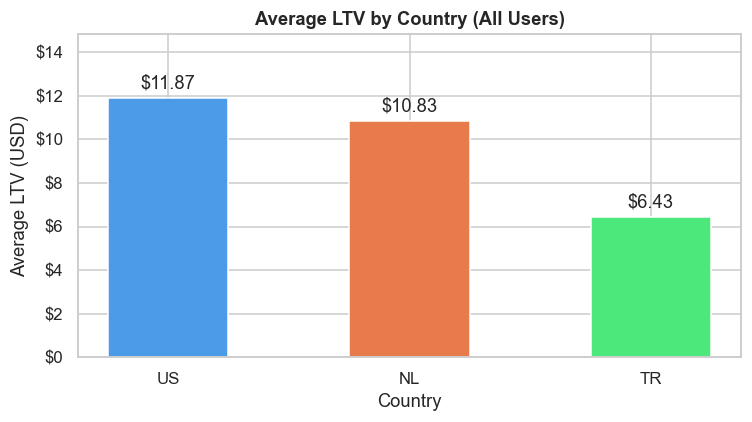

Insight: LTV is calculated across all users (non-paying users are included with $0 revenue).
US: $11.87 avg LTV (161/340 users paid). NL: $10.83 (149/308). TR: $6.43 (171/354). TR's lower LTV reflects both its lower price point (~$4.99/mo vs ~$8.99–$9.99/mo for NL/US) and a lower payment conversion rate.


In [12]:
sql_t6 = """
SELECT
    u.country,
    COUNT(DISTINCT u.id) AS total_users,
    COUNT(DISTINCT CASE WHEN e.amount_usd > 0 THEN u.id END) AS paying_users,
    ROUND(SUM(COALESCE(e.amount_usd, 0)) / COUNT(DISTINCT u.id), 2) AS avg_ltv_usd
FROM users u
LEFT JOIN user_events e
    ON u.id = e.user_id
    AND e.event_name IN ('subscription_started', 'subscription_renewed')
GROUP BY u.country
ORDER BY avg_ltv_usd DESC
"""

df6 = q(sql_t6)
display(df6)

colors_t6 = [COUNTRY_COLORS[c] for c in df6["country"]]
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(df6["country"], df6["avg_ltv_usd"], color=colors_t6, width=0.5)
ax.bar_label(bars, fmt="$%.2f", padding=4)
ax.set_title("Average LTV by Country (All Users)", fontweight="bold")
ax.set_ylabel("Average LTV (USD)")
ax.set_xlabel("Country")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("$%.0f"))
ax.set_ylim(0, df6["avg_ltv_usd"].max() * 1.25)
plt.tight_layout()
plt.show()

us_ltv   = float(df6[df6["country"] == "US"]["avg_ltv_usd"].values[0])
nl_ltv   = float(df6[df6["country"] == "NL"]["avg_ltv_usd"].values[0])
tr_ltv   = float(df6[df6["country"] == "TR"]["avg_ltv_usd"].values[0])
us_paying = int(df6[df6["country"] == "US"]["paying_users"].values[0])
nl_paying = int(df6[df6["country"] == "NL"]["paying_users"].values[0])
tr_paying = int(df6[df6["country"] == "TR"]["paying_users"].values[0])
us_total  = int(df6[df6["country"] == "US"]["total_users"].values[0])
nl_total  = int(df6[df6["country"] == "NL"]["total_users"].values[0])
tr_total  = int(df6[df6["country"] == "TR"]["total_users"].values[0])

print(
    f"Insight: LTV is calculated across all users "
    f"(non-paying users are included with $0 revenue).\n"
    f"US: ${us_ltv:.2f} avg LTV ({us_paying}/{us_total} users paid). "
    f"NL: ${nl_ltv:.2f} ({nl_paying}/{nl_total}). "
    f"TR: ${tr_ltv:.2f} ({tr_paying}/{tr_total}). "
    f"TR's lower LTV reflects both its lower price point (~$4.99/mo vs "
    f"~$8.99–$9.99/mo for NL/US) and a lower payment conversion rate."
)

## Task 7. Dashboard (Next.js)
### Implemented under dashboard/ directory.
### See dashboard/app/api/subscription-revenue-breakdown/route.ts and dashboard/app/page.tsx


## Task 8 (Bonus). Predicted Lifetime Value (pLTV) for User #1001 (Bruce Wayne)

### Methodology & Assumptions

#### **User profile:**
#### - Country: US → price point **$9.99/month**
#### - Source: Instagram → Paid channel
#### - Status: 1 payment (`subscription_started` 2025-02-25), no subsequent renewal or cancellation event in DB as of 2025-07-12

### **Approach: Two Layers:**

#### 1. **Cohort median (primary estimate):** Find all historical subscribers who share the same profile (US + Instagram) and observe their realised total spend. The median gives a robust, outlier-resistant pLTV benchmark for Bruce.

#### 2. **Expected-value model (secondary estimate):** Use the empirical payment-level survival curve from the same cohort to project expected total payments.
####    - `survival(k)` = fraction of cohort users who made at least *k* payments
####    - `E[total payments]` = Σ survival(k) for k = 1, 2, …
####    - `pLTV = E[total payments] × price`

**Assumptions:**
#### - All subscriptions are monthly at a fixed price per country.
#### - The US + Instagram cohort is a valid behavioural proxy for Bruce.
#### - Active subscribers (no cancellation) contribute observed payments up to the analysis date only I do **not** assume they continue beyond that (conservative).
#### - Bruce has already passed the trial-cancel risk by converting directly to a subscription, placing him in the **highest-intent segment**.

In [13]:
bruce_date = q("SELECT created_at FROM user_events WHERE user_id = 1001 AND event_name = 'subscription_started'").iloc[0, 0][:10]
print(f"Bruce's subscription start: {bruce_date}")

Bruce's subscription start: 2025-02-25


In [14]:
# Cohort-median approach
sql_t8_cohort = """
SELECT
    e.user_id,
    SUM(e.amount_usd) AS realised_ltv
FROM user_events e
JOIN users u ON u.id = e.user_id
WHERE u.country = 'US'
  AND u.attribution_source = 'instagram'
  AND e.event_name IN ('subscription_started', 'subscription_renewed')
  AND u.id != 1001            -- exclude Bruce himself
GROUP BY e.user_id
"""

df8_cohort = q(sql_t8_cohort)
median_ltv = df8_cohort["realised_ltv"].median()
mean_ltv   = df8_cohort["realised_ltv"].mean()

print("=== Cohort: US + Instagram subscribers ===")
print(df8_cohort["realised_ltv"].describe().round(2))
print(f"\nMedian realised LTV : ${median_ltv:.2f}")
print(f"Mean realised LTV   : ${mean_ltv:.2f}")

=== Cohort: US + Instagram subscribers ===
count    43.00
mean     25.79
std      11.99
min       9.99
25%      19.98
50%      29.97
75%      29.97
max      49.95
Name: realised_ltv, dtype: float64

Median realised LTV : $29.97
Mean realised LTV   : $25.79


In [15]:
# Expected-value / retention-curve approach 
sql_t8_payments = """
SELECT
    e.user_id,
    e.created_at,
    e.event_name
FROM user_events e
JOIN users u ON u.id = e.user_id
WHERE u.country = 'US'
  AND u.attribution_source = 'instagram'
  AND e.event_name IN ('subscription_started', 'subscription_renewed')
  AND u.id != 1001
ORDER BY e.user_id, e.created_at
"""

df8_pay = q(sql_t8_payments)

# Rank each payment within a user (1 = subscription_started)
df8_pay["payment_rank"] = (
    df8_pay.groupby("user_id")["created_at"].rank(method="first").astype(int)
)

n_total = df8_pay["user_id"].nunique()

# Fraction of cohort still paying at payment k
survival = (
    df8_pay.groupby("payment_rank")["user_id"].nunique()
    / n_total
)

PRICE_US = 9.99
expected_payments = survival.sum()          # E[total payments]
pltv_ev = round(expected_payments * PRICE_US, 2)

print("=== Survival curve (fraction of cohort still paying at payment k) ===")
print(survival.round(3).to_string())
print(f"\nExpected total payments : {expected_payments:.2f}")
print(f"pLTV (EV model)         : ${pltv_ev:.2f}")

=== Survival curve (fraction of cohort still paying at payment k) ===
payment_rank
1    1.000
2    0.767
3    0.558
4    0.163
5    0.093

Expected total payments : 2.58
pLTV (EV model)         : $25.79


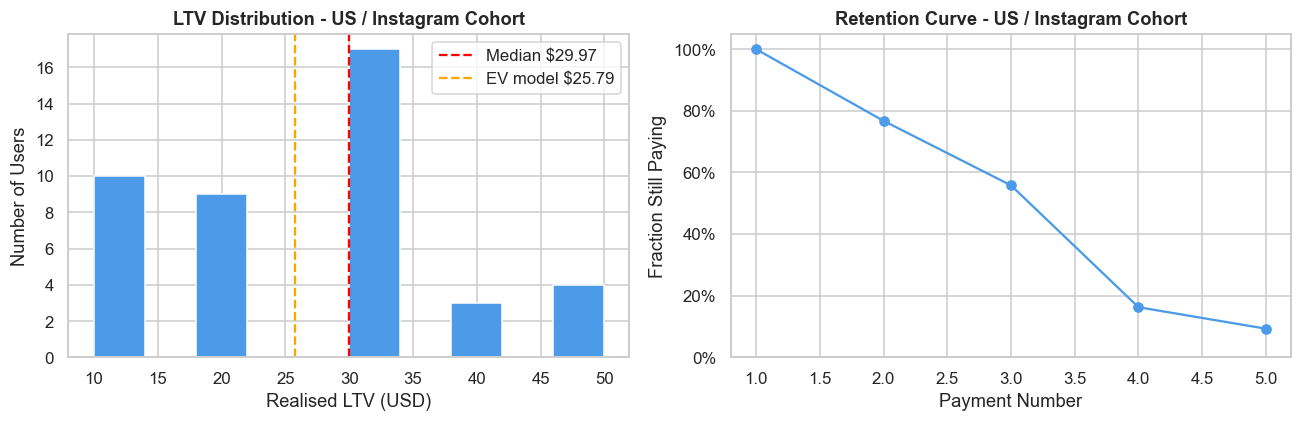

In [16]:
# Visualise both estimates
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: LTV distribution of cohort
axes[0].hist(df8_cohort["realised_ltv"], bins=10, color="#4C9BE8", edgecolor="white")
axes[0].axvline(median_ltv, color="red",    linestyle="--", label=f"Median ${median_ltv:.2f}")
axes[0].axvline(pltv_ev,   color="orange", linestyle="--", label=f"EV model ${pltv_ev:.2f}")
axes[0].set_title("LTV Distribution - US / Instagram Cohort", fontweight="bold")
axes[0].set_xlabel("Realised LTV (USD)")
axes[0].set_ylabel("Number of Users")
axes[0].legend()

# Right: survival curve
axes[1].plot(survival.index, survival.values, marker="o", color="#4C9BE8")
axes[1].set_title("Retention Curve - US / Instagram Cohort", fontweight="bold")
axes[1].set_xlabel("Payment Number")
axes[1].set_ylabel("Fraction Still Paying")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[1].set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

In [17]:
# Bootstrap Confidence Intervals
# Why: the cohort contains only 43 users, which is a relatively small sample.
# I use bootstrap resampling to estimate confidence intervals
# and quantify the uncertainty of our pLTV estimates.

np.random.seed(42)
N_BOOT = 10_000
ltvs = df8_cohort["realised_ltv"].values

# 95% CI for cohort median
boot_medians = np.array([
    np.median(np.random.choice(ltvs, size=len(ltvs), replace=True))
    for _ in range(N_BOOT)
])
ci_median_low, ci_median_high = np.percentile(boot_medians, [2.5, 97.5])

# 95% CI for expected value (mean)
boot_means = np.array([
    np.mean(np.random.choice(ltvs, size=len(ltvs), replace=True))
    for _ in range(N_BOOT)
])
ci_ev_low, ci_ev_high = np.percentile(boot_means, [2.5, 97.5])

print(f"Cohort size        : {len(ltvs)} users  <-- small sample, confidence intervals may be wide")
print(f"Median pLTV        : ${median_ltv:.2f}  |  95% CI: [${ci_median_low:.2f}, ${ci_median_high:.2f}]")
print(f"EV (mean) pLTV     : ${pltv_ev:.2f}  |  95% CI: [${ci_ev_low:.2f}, ${ci_ev_high:.2f}]")

Cohort size        : 43 users  <-- small sample, confidence intervals may be wide
Median pLTV        : $29.97  |  95% CI: [$19.98, $29.97]
EV (mean) pLTV     : $25.79  |  95% CI: [$22.30, $29.27]


In [18]:
# Summary
print("========================================")
print(" pLTV Estimate for User #1001 (Bruce Wayne)")
print("========================================")
print(f" Country        : US | Source: Instagram")
print(f" Price point    : ${PRICE_US}/month")
print(f" Current status : 1 payment recorded (subscription_started {bruce_date}), "
      f"no subsequent renewal or cancellation event in DB as of {ANALYSIS_DATE}")
print()
print(f" Method 1 Cohort median  : ${median_ltv:.2f}  ({int(round(median_ltv / PRICE_US))} payments)")
print(f"   --> Median realised LTV of {len(ltvs)} US/Instagram subscribers")
print()
print(f" Method 2 EV retention   : ${pltv_ev:.2f}  ({expected_payments:.1f} expected payments)")
print(f"   --> Σ survival(k) × ${PRICE_US} using empirical payment-level retention curve")
print()
print(f" 95% Bootstrap CI (n={len(ltvs)} users):")
print(f"   Cohort median : [${ci_median_low:.2f}, ${ci_median_high:.2f}]")
print(f"   EV model      : [${ci_ev_low:.2f},  ${ci_ev_high:.2f}]")
print()
print(f" --> Primary estimate: ${median_ltv:.2f} (cohort median, outlier-resistant)")
print(f"     Secondary estimate: ${pltv_ev:.2f} (EV model, consistent with median)")
print()
print("Key observations:")
print(f" - Bruce converted from trial to subscription on the same day highest-intent signal.")
print(f" - Month 3 is the critical churn point in this cohort (survival drops ~55% → ~16%).")
print(f"   A targeted retention intervention at that stage could meaningfully increase pLTV.")
print(f" - Cohort n={len(ltvs)} is small CIs are wide. Estimate becomes more reliable as cohort grows.")
print(f" - Both estimates are conservative: active subs are censored at {ANALYSIS_DATE}.")
print(f" - The two methods converge closely (${median_ltv:.2f} vs ${pltv_ev:.2f}), increasing confidence")
print(f"   in the estimate despite the small sample size.")
print()
print("Caveats & assumptions:")
print(f" - All US subscriptions assumed at fixed ${PRICE_US}/month price point.")
print(f" - US + Instagram cohort used as behavioural proxy for Bruce.")
print(f" - Active subscribers contribute observed payments only up to {ANALYSIS_DATE} (conservative).")
print(f" - No external factors (price changes, product updates) are modelled.")

 pLTV Estimate for User #1001 (Bruce Wayne)
 Country        : US | Source: Instagram
 Price point    : $9.99/month
 Current status : 1 payment recorded (subscription_started 2025-02-25), no subsequent renewal or cancellation event in DB as of 2025-07-12

 Method 1 Cohort median  : $29.97  (3 payments)
   --> Median realised LTV of 43 US/Instagram subscribers

 Method 2 EV retention   : $25.79  (2.6 expected payments)
   --> Σ survival(k) × $9.99 using empirical payment-level retention curve

 95% Bootstrap CI (n=43 users):
   Cohort median : [$19.98, $29.97]
   EV model      : [$22.30,  $29.27]

 --> Primary estimate: $29.97 (cohort median, outlier-resistant)
     Secondary estimate: $25.79 (EV model, consistent with median)

Key observations:
 - Bruce converted from trial to subscription on the same day highest-intent signal.
 - Month 3 is the critical churn point in this cohort (survival drops ~55% → ~16%).
   A targeted retention intervention at that stage could meaningfully increas

In [19]:
conn.close()
print("Done.")

Done.
